# Example: GloVe Embeddings from Scratch
In this example, we train a GloVe (Global Vectors for Word Representation) model on a toy corpus extended from the one used in L9a and L9c. GloVe learns word embeddings by factorizing a weighted log co-occurrence matrix, combining the strengths of count-based and prediction-based methods. After training, we compute cosine similarities for selected word pairs so the student can compare these results to the CBOW and Skip-Gram embeddings from L9a and L9c.

> __Learning Objectives:__
> 
> By the end of this example, you should be able to:
>
> * __Co-occurrence matrix construction__: Build a weighted co-occurrence matrix from a corpus using distance-based weighting within a sliding window. Understand how closer words receive higher co-occurrence counts through the $1/\delta$ weighting scheme.
> * __GloVe training__: Train GloVe embeddings by minimizing a weighted least-squares objective over non-zero co-occurrence entries. Monitor the loss curve to verify convergence of the embedding parameters.
> * __Embedding comparison__: Extract final GloVe embeddings by combining word and context vectors into a single representation. Compute cosine similarities for selected word pairs and compare to prediction-based methods such as CBOW and Skip-Gram.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Data
We extend the toy corpus from L9a with two additional sentences that increase the co-occurrence overlap between synonyms such as "love" and "enjoy." Let's construct the `sentences::Array{String,1}` variable containing our corpus.

In [2]:
sentences = let

    # initialize -
    sentences_array = Array{String,1}(); # initialize an array of sentence strings

    # add sentences -
    push!(sentences_array, "I love machine learning and data science .");
    push!(sentences_array, "Machine learning is fun .");
    push!(sentences_array, "Machine learning is great .");
    push!(sentences_array, "I love coding machine learning in Julia !");
    push!(sentences_array, "Julia is a great programming language ?");
    push!(sentences_array, "I enjoy learning new things about data science , machine learning , and artificial intelligence .");
    push!(sentences_array, "I enjoy coding and love programming in Julia .");
    push!(sentences_array, "Claude and I love coding in Julia .");
    
    # return the array
    sentences_array
end

8-element Vector{String}:
 "I love machine learning and data science ."
 "Machine learning is fun ."
 "Machine learning is great ."
 "I love coding machine learning in Julia !"
 "Julia is a great programming language ?"
 "I enjoy learning new things abo" ⋯ 35 bytes ⋯ ", and artificial intelligence ."
 "I enjoy coding and love programming in Julia ."
 "Claude and I love coding in Julia ."

Next, we build the vocabulary in the `vocabulary::Dict{String, Int64}` variable, where keys are unique words and values are their indices, and the inverse vocabulary in the `inverse_vocabulary::Dict{Int64, String}` variable, where keys are indices and values are words.

In [3]:
vocabulary, inverse_vocabulary = let

    # initialize -
    vocabulary = Dict{String, Int64}();
    inverse_vocabulary = Dict{Int64, String}();
    index = 1;

    # control tokens -
    control_tokens = ["<bos>", "<eos>", "<pad>", "<unk>"];

    # tmp variables -
    words = Set{String}();
    for sentence in sentences
        tmp = split(lowercase(sentence));
        push!(words, tmp...);
    end
    words_array = collect(words) |> sort;

    # append the control tokens to the words array
    words_array = vcat(words_array, control_tokens);
    for word in words_array
        vocabulary[word] = index;
        inverse_vocabulary[index] = word;
        index += 1;
    end

    # return the vocabulary and inverse vocabulary
    (vocabulary, inverse_vocabulary)
end

(Dict("!" => 1, "is" => 18, "enjoy" => 12, "data" => 11, "language" => 20, "coding" => 10, "science" => 26, "<bos>" => 28, "a" => 5, "and" => 7…), Dict(5 => "a", 16 => "in", 20 => "language", 12 => "enjoy", 24 => "new", 28 => "<bos>", 8 => "artificial", 17 => "intelligence", 30 => "<pad>", 1 => "!"…))

In [4]:
vocabulary

Dict{String, Int64} with 31 entries:
  "!"           => 1
  "is"          => 18
  "enjoy"       => 12
  "data"        => 11
  "language"    => 20
  "coding"      => 10
  "science"     => 26
  "<bos>"       => 28
  "a"           => 5
  "and"         => 7
  ","           => 2
  "programming" => 25
  "love"        => 22
  "?"           => 4
  "."           => 3
  "in"          => 16
  "i"           => 15
  "<unk>"       => 31
  "about"       => 6
  ⋮             => ⋮

### Implementations
We define some helper functions that we use for the GloVe example. In the `cosine_sim(...)` function, we compute the cosine similarity between two word vectors given their indices in the embedding matrix. 

In [5]:
function cosine_sim(w1::String, w2::String, E::Matrix{Float64}, vocab::Dict{String, Int64})
    haskey(vocab, w1) || return (println("  ⚠ \"$(w1)\" not in vocabulary"); NaN);
    haskey(vocab, w2) || return (println("  ⚠ \"$(w2)\" not in vocabulary"); NaN);
    v1 = E[:, vocab[w1]]; # get the embedding vector for word w1
    v2 = E[:, vocab[w2]]; # get the embedding vector for word w2
    return dot(v1, v2) / (norm(v1) * norm(v2)); # compute and return the cosine similarity
end

cosine_sim (generic function with 1 method)

___

## Task 1: Build Weighted Co-occurrence Matrix
GloVe operates on a global word-word co-occurrence matrix rather than individual (context, target) training pairs. We construct this matrix by sliding a window over each sentence and accumulating distance-weighted counts.

> __Distance-weighted co-occurrence__
>
> For each center word at position $t$ and a context word at position $t + \delta$ (where $1 \leq |\delta| \leq c$ for window size $c$), we add $1/|\delta|$ to the co-occurrence count $X_{ij}$. 
>
> Closer words receive higher weight because they are more likely to be syntactically or semantically related. This produces a symmetric matrix $\mathbf{X}\in\mathbb{R}^{N_{\mathcal{V}}\times N_{\mathcal{V}}}$ where each entry reflects the total weighted co-occurrence between two words across the corpus.

We store the result in the `X::Array{Float64, 2}` variable by calling [the `build_weighted_cooccurrence_matrix(...)` function](src/GloVe.jl).

In [6]:
X = build_weighted_cooccurrence_matrix(sentences, vocabulary, window_size = 2);
println("Co-occurrence matrix size: $(size(X)), non-zero entries: $(count(X .> 0))")

Co-occurrence matrix size: (31, 31), non-zero entries: 200


In [7]:
X

31×31 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  1.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.5     0.0  1.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.5     0.0  1.0  0.0  0.0  6.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.5  0.0  0.0  0.0  1.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.5  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.5  1.0  0.0  0.0  0.0  0.0
 0.0  1.0  0.0  0.0  0.0  0.0  0.0  1.0     0.5  0.5  0.0  0.5  0.0  0.0  0.0
 0.0  0.5  0.5  0.0  0.0  0.0  1.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0     0.0  0.0  0.0  1.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                        ⋮              ⋱       ⋮                        ⋮
 0.0  1.5  0.0  0.0  0.0  0.0  0.5  0.0     0.0  0.5  0.0  2.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.5  0.0  0.0    

Let's inspect a few entries to verify the co-occurrence counts.

In [8]:
let
    
    # initialize -
    check_pairs = [("machine", "learning"), ("data", "science"), ("fun", "great"), ("machine", "?"), 
        ("julia", "programming"), ("love", "enjoy"), ("santa", "claus")];
    
    # let's iterate through the check pairs and print the co-occurrence values
    for (w1, w2) ∈ check_pairs
        
        # we need to check if both words are in the vocabulary before we can access their co-occurrence value in the matrix
        if !haskey(vocabulary, w1) || !haskey(vocabulary, w2)
            missing_word = !haskey(vocabulary, w1) ? w1 : w2;
            println("X[$(w1), $(w2)] = ⚠ \"$(missing_word)\" not in vocabulary");
            continue;
        end

        # get the indices for the words in the vocabulary (both of these are in the vocabulary since we checked above)
        i = vocabulary[w1]; # get the index for word w1 in the vocabulary
        j = vocabulary[w2]; # get the index for word w2 in the vocabulary
        println("X[$(w1), $(w2)] = $(round(X[i, j], digits=4))"); # print the co-occurrence value for the pair (w1, w2)
    end
end

X[machine, learning] = 5.0
X[data, science] = 2.0
X[fun, great] = 0.0
X[machine, ?] = 0.0
X[julia, programming] = 0.5
X[love, enjoy] = 0.0
X[santa, claus] = ⚠ "santa" not in vocabulary


___

## Task 2: Train GloVe Embeddings
In this task, we will train GloVe embeddings using the co-occurrence matrix we built in Task 1. The GloVe model learns two sets of embeddings: word vectors $\mathbf{w}_i$ and context vectors $\tilde{\mathbf{w}}_j$, along with bias terms $b_i$ and $\tilde{b}_j$. The training objective minimizes the weighted least-squares difference between the dot product of the embeddings and the log of the co-occurrence counts.

> __GloVe objective__
>
> For each word pair $(i,j)$ where $X_{ij} > 0$, the GloVe loss is: $J = \sum_{i,j} f(X_{ij})\left(\mathbf{w}_i^\top \tilde{\mathbf{w}}_j + b_i + \tilde{b}_j - \log X_{ij}\right)^2$ where $f(X_{ij}) = \min\left(1, (X_{ij}/x_{\max})^\alpha\right)$ is a weighting function that prevents very frequent co-occurrences from dominating the loss. The parameters $\mathbf{w}_i, \tilde{\mathbf{w}}_j\in\mathbb{R}^d$ are word and context embedding vectors, and $b_i, \tilde{b}_j\in\mathbb{R}$ are scalar bias terms.

We call [the `train_glove(...)` function](src/GloVe.jl) and store the results in five variables: `W_word::Matrix{Float64}` (word embeddings of shape $d \times N_{\mathcal{V}}$), `W_ctx::Matrix{Float64}` (context embeddings), `b_word::Vector{Float64}` (word biases), `b_ctx::Vector{Float64}` (context biases), and `loss_history::Vector{Float64}` (per-epoch average loss).

__Note__: Our implementation uses vanilla stochastic gradient descent (SGD) with a fixed learning rate for simplicity. The original GloVe paper uses AdaGrad, which adapts the learning rate per parameter. We will implement AdaGrad in the lab.

In [9]:
W_word, W_ctx, b_word, b_ctx, loss_history = train_glove(X, length(vocabulary), d = 5, η = 0.05, num_epochs = 1000);
println("Training complete. Final average loss: $(round(loss_history[end], digits=4))")

Training complete. Final average loss: 0.0002


Let's plot the training loss to verify that the model converges.

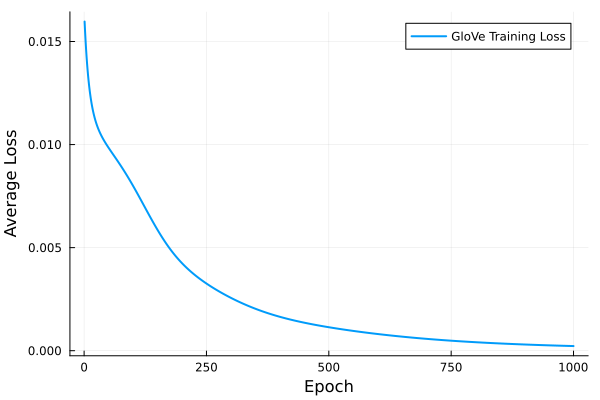

In [10]:
let
    plot(loss_history, xlabel="Epoch", ylabel="Average Loss", label="GloVe Training Loss", lw=2)
end

___

## Task 3: Compare Embeddings
The GloVe authors recommend combining the word and context vectors as the final embedding, since both capture useful information. We compute cosine similarities for the same word pairs used in L9a and L9c so the student can visually compare GloVe to CBOW and Skip-Gram.

> __Combining word and context vectors__
>
> Because GloVe treats word and context vectors symmetrically, the final embedding for word $i$ is $\mathbf{e}_i = \mathbf{w}_i + \tilde{\mathbf{w}}_i$. This combination leverages information from both roles (center and context) and typically produces better embeddings than using either vector alone. We measure similarity using cosine similarity: $\cos(\mathbf{e}_i, \mathbf{e}_j) = \mathbf{e}_i \cdot \mathbf{e}_j / (\|\mathbf{e}_i\|_2 \|\mathbf{e}_j\|_2)$.

We store the combined embeddings in the `embeddings::Matrix{Float64}` variable of shape $d \times N_{\mathcal{V}}$.

In [11]:
embeddings = W_word + W_ctx;
println("Combined embedding matrix size: $(size(embeddings))")

Combined embedding matrix size: (5, 31)


In [12]:
embeddings

5×31 Matrix{Float64}:
 -0.270114  -0.620328    -1.74945   …  -1.60832    0.0471219  -0.163355
 -0.315716  -0.609371    -0.865899     -0.869915  -0.168585   -0.109606
 -0.201054  -0.50138     -0.640294     -0.268288  -0.0729609  -0.138585
  0.109442  -0.00739564  -0.425449     -0.316466  -0.0273096  -0.278973
  0.054273  -0.00543364   0.904974      1.06913    0.188759    0.169218

Now let's compute cosine similarities for selected word pairs and display the results in a table.

In [13]:
let
    
    # initialize the word pairs we want to check the cosine similarity for
    word_pairs = [
        ("machine", "learning"),
        ("data", "science"),
        ("fun", "great"),
        ("love", "enjoy"),
        ("machine", "?"),
        ("julia", "enjoy")
    ];

    # build the results table -
    pair_labels = ["$(w1) / $(w2)" for (w1, w2) ∈ word_pairs]; # this is an array comprehension that creates labels for the word pairs
    similarities = [round(cosine_sim(w1, w2, embeddings, vocabulary), digits=4) for (w1, w2) ∈ word_pairs];

    # make a DataFrame, and then show it with PrettyTables.jl
    df = DataFrame("Word Pair" => pair_labels, "GloVe Cosine Similarity" => similarities);
    pretty_table(df, 
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact));
end

 -------------------- -------------------------
           Word Pair   GloVe Cosine Similarity 
              String                   Float64 
 -------------------- -------------------------
  machine / learning                    0.9751
      data / science                     0.942
         fun / great                     0.973
        love / enjoy                   -0.0977
         machine / ?                   -0.2749
       julia / enjoy                    0.0127
 -------------------- -------------------------


__What's it mean when we have a positive (negative) cosine similarity?__ Cosine similarity indicates that the two word vectors are pointing in the same (opposite) directions in the embedding space. This suggests that the words have the same (different) contexts and are likely to be semantically related (unrelated) in meaning. 

* __Positive cosine similarity__: The word vectors point in __similar__ directions, indicating that the words have similar contexts and are likely to be semantically related. For example, "king" and "queen" might have a high positive cosine similarity because they often appear in similar contexts (royalty, monarchy).
* __Negative cosine similarity__: The word vectors point in __opposite__ directions, suggesting that the words have different contexts and are likely to be semantically unrelated or even antonyms. For example, "hot" and "cold" might have a negative cosine similarity because they appear in different contexts and convey

Let's visualize the results by doing a dimensionality reduction (e.g., PCA) on the embeddings and plotting the selected word pairs in 2D space.

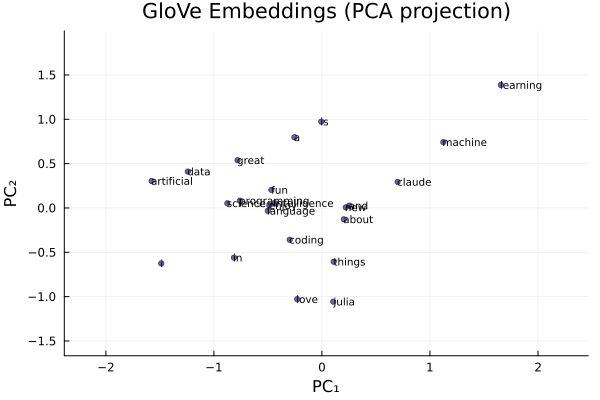

In [14]:
let
    # initialize -
    E = Float64.(embeddings); # convert the embeddings to Float64 type for numerical stability in PCA
    μ = mean(E, dims=2); # compute the mean embedding vector across all words (mean of each row)
    E_centered = E .- μ; # center the embeddings and compute PCA projection -

    # SVD to get top 2 principal components -
    U, S, V = svd(E_centered');
    Z = V[:, 1:2]' * E_centered; # project onto top 2 PCs (2 x N)

    # filter out control tokens and punctuation -
    skip = Set(["<bos>", "<eos>", "<pad>", "<unk>", ".", "!", "?", ","]);
    keep = [idx for idx ∈ 1:size(E, 2) if inverse_vocabulary[idx] ∉ skip]; # ∉ \notin
    
    # add margin so labels on the edges aren't clipped -
    x_vals = Z[1, keep];
    y_vals = Z[2, keep];
    x_margin = 0.25 * (maximum(x_vals) - minimum(x_vals));
    y_margin = 0.25 * (maximum(y_vals) - minimum(y_vals));

    # plot only the kept words -
    p = scatter(x_vals, y_vals, ms=3, alpha=0.6, label="", color = :navy,
        xlabel="PC₁", ylabel="PC₂", title="GloVe Embeddings (PCA projection)",
        xlims=(minimum(x_vals) - x_margin, maximum(x_vals) + x_margin),
        ylims=(minimum(y_vals) - y_margin, maximum(y_vals) + y_margin));
    
    for idx in keep
        word = inverse_vocabulary[idx];
        annotate!(p, Z[1, idx], Z[2, idx], text(word, :left, 7));
    end
    p
end

___

## Summary
In this example, we trained GloVe embeddings from scratch on a toy corpus by constructing a weighted co-occurrence matrix and minimizing a weighted least-squares objective.

> __Key Takeaways__:
> 
> * __Distance-weighted co-occurrence captures global statistics__: The co-occurrence matrix accumulates $1/\delta$ weights for each word pair within a sliding window across the entire corpus. This global counting approach contrasts with prediction-based methods like CBOW and Skip-Gram, which process local context windows one at a time.
> * __Weighted least-squares training avoids softmax__: GloVe minimizes a regression-style loss over non-zero co-occurrence entries with a capping function $f(X_{ij})$ that limits the influence of very frequent pairs. This avoids the expensive softmax normalization required by CBOW and Skip-Gram.
> * __Combined word and context vectors form the final embedding__: Because GloVe treats center and context roles symmetrically, adding the two learned vectors for each word produces a single embedding. The student can compare the cosine similarities from this table to the CBOW and Skip-Gram results in L9a and L9c.

These results show how a count-based factorization method produces word embeddings that can be directly compared to those from prediction-based models.
___